In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

DATA_PATH = "/kaggle/input/competitions/store-sales-time-series-forecasting"

train_path = os.path.join(DATA_PATH, "train.csv")

sales_df = pd.read_csv(
    train_path,
    parse_dates=["date"]
)

print("Dataset loaded successfully")
print("Original rows:", len(sales_df))
print("Date range:", sales_df["date"].min(), "to", sales_df["date"].max())
print("Number of stores:", sales_df["store_nbr"].nunique())
print("Number of product families:", sales_df["family"].nunique())

Dataset loaded successfully
Original rows: 3000888
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Number of stores: 54
Number of product families: 33


In [2]:
category_daily = (
    sales_df
    .groupby(["date", "family"], as_index=False)
    .agg(
        sales=("sales", "sum"),
        onpromotion=("onpromotion", "sum")
    )
)

category_daily = category_daily.sort_values(
    ["family", "date"]
).reset_index(drop=True)

print("Category-level rows:", len(category_daily))
print("Number of product families:", category_daily["family"].nunique())
print("Number of dates:", category_daily["date"].nunique())

print("\nFirst records:")
print(category_daily.head(10))

Category-level rows: 55572
Number of product families: 33
Number of dates: 1684

First records:
        date      family  sales  onpromotion
0 2013-01-01  AUTOMOTIVE    0.0            0
1 2013-01-02  AUTOMOTIVE  255.0            0
2 2013-01-03  AUTOMOTIVE  161.0            0
3 2013-01-04  AUTOMOTIVE  169.0            0
4 2013-01-05  AUTOMOTIVE  342.0            0
5 2013-01-06  AUTOMOTIVE  360.0            0
6 2013-01-07  AUTOMOTIVE  189.0            0
7 2013-01-08  AUTOMOTIVE  229.0            0
8 2013-01-09  AUTOMOTIVE  164.0            0
9 2013-01-10  AUTOMOTIVE  164.0            0


In [3]:
df = category_daily.copy()

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_month"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_number"] = df["date"].dt.isocalendar().week.astype(int)

df["sales_lag_7"] = (
    df.groupby("family")["sales"]
    .shift(7)
)

df["sales_lag_14"] = (
    df.groupby("family")["sales"]
    .shift(14)
)

df["sales_lag_28"] = (
    df.groupby("family")["sales"]
    .shift(28)
)

df["rolling_mean_7"] = (
    df.groupby("family")["sales"]
    .transform(
        lambda values: values.shift(1).rolling(7).mean()
    )
)

df["rolling_mean_28"] = (
    df.groupby("family")["sales"]
    .transform(
        lambda values: values.shift(1).rolling(28).mean()
    )
)

df = df.dropna(
    subset=[
        "sales_lag_7",
        "sales_lag_14",
        "sales_lag_28",
        "rolling_mean_7",
        "rolling_mean_28"
    ]
).copy()

print("Rows after feature engineering:", len(df))
print("Missing feature values:", df.isnull().sum().sum())

Rows after feature engineering: 54648
Missing feature values: 0


In [4]:
train_df = df[df["date"] < "2016-07-01"].copy()

validation_df = df[
    (df["date"] >= "2016-07-01") &
    (df["date"] < "2017-01-01")
].copy()

test_df = df[
    df["date"] >= "2017-01-01"
].copy()

print("Training period:")
print(
    train_df["date"].min(),
    "to",
    train_df["date"].max()
)
print("Rows:", len(train_df))

print("\nValidation period:")
print(
    validation_df["date"].min(),
    "to",
    validation_df["date"].max()
)
print("Rows:", len(validation_df))

print("\nTest period:")
print(
    test_df["date"].min(),
    "to",
    test_df["date"].max()
)
print("Rows:", len(test_df))

Training period:
2013-01-29 00:00:00 to 2016-06-30 00:00:00
Rows: 41118

Validation period:
2016-07-01 00:00:00 to 2016-12-31 00:00:00
Rows: 6039

Test period:
2017-01-01 00:00:00 to 2017-08-15 00:00:00
Rows: 7491


In [5]:
numeric_features = [
    "onpromotion",
    "year",
    "month",
    "day_of_month",
    "day_of_week",
    "week_number",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_28",
    "rolling_mean_7",
    "rolling_mean_28"
]

categorical_features = [
    "family"
]

feature_columns = numeric_features + categorical_features
target_column = "sales"

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("Input features:", feature_columns)

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

Input features: ['onpromotion', 'year', 'month', 'day_of_month', 'day_of_week', 'week_number', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_28', 'family']

Training shape: (41118, 12)
Validation shape: (6039, 12)
Test shape: (7491, 12)


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [7]:
def evaluate_predictions(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    predicted = np.clip(predicted, 0, None)

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    non_zero_mask = actual > 0

    mape = np.mean(
        np.abs(
            (
                actual[non_zero_mask]
                - predicted[non_zero_mask]
            )
            / actual[non_zero_mask]
        )
    ) * 100

    wmape = (
        np.sum(
            np.abs(actual - predicted)
        )
        / np.sum(np.abs(actual))
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "WMAPE (%)": wmape
    }


print("Evaluation functions created successfully.")

Evaluation functions created successfully.


In [8]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=18,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=3,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    )
}

trained_models = {}
validation_results = []

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

    print(f"Training {model_name}...")

    pipeline.fit(
        X_train,
        y_train
    )

    validation_predictions = pipeline.predict(
        X_validation
    )

    metrics = evaluate_predictions(
        y_validation,
        validation_predictions
    )

    validation_results.append(
        {
            "Algorithm": model_name,
            "MAE": round(metrics["MAE"], 2),
            "RMSE": round(metrics["RMSE"], 2),
            "MAPE (%)": round(metrics["MAPE (%)"], 2),
            "WMAPE (%)": round(metrics["WMAPE (%)"], 2)
        }
    )

    trained_models[model_name] = pipeline

    print(
        f"{model_name} completed | "
        f"MAE: {metrics['MAE']:.2f} | "
        f"RMSE: {metrics['RMSE']:.2f} | "
        f"MAPE: {metrics['MAPE (%)']:.2f}% | "
        f"WMAPE: {metrics['WMAPE (%)']:.2f}%"
    )


validation_results_df = pd.DataFrame(
    validation_results
)

validation_results_df = (
    validation_results_df
    .sort_values("WMAPE (%)")
    .reset_index(drop=True)
)

print("\nValidation Model Comparison")
print(validation_results_df.to_string(index=False))

Training Linear Regression...
Linear Regression completed | MAE: 2596.81 | RMSE: 7934.90 | MAPE: 301.70% | WMAPE: 10.69%
Training Decision Tree...
Decision Tree completed | MAE: 2782.52 | RMSE: 9164.59 | MAPE: 65.65% | WMAPE: 11.46%
Training Random Forest...
Random Forest completed | MAE: 2068.01 | RMSE: 7136.94 | MAPE: 30.37% | WMAPE: 8.52%

Validation Model Comparison
        Algorithm     MAE    RMSE  MAPE (%)  WMAPE (%)
    Random Forest 2068.01 7136.94     30.37       8.52
Linear Regression 2596.81 7934.90    301.70      10.69
    Decision Tree 2782.52 9164.59     65.65      11.46


In [9]:
rf_configs = [
    {
        "name": "RF_Config_1",
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_leaf": 3,
        "max_features": "sqrt"
    },
    {
        "name": "RF_Config_2",
        "n_estimators": 150,
        "max_depth": 24,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    },
    {
        "name": "RF_Config_3",
        "n_estimators": 150,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": 0.7
    }
]

rf_tuning_results = []
rf_tuned_models = {}

for config in rf_configs:
    print(f"Training {config['name']}...")

    rf_model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        n_jobs=-1,
        random_state=42
    )

    rf_pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", rf_model)
        ]
    )

    rf_pipeline.fit(
        X_train,
        y_train
    )

    predictions = rf_pipeline.predict(
        X_validation
    )

    metrics = evaluate_predictions(
        y_validation,
        predictions
    )

    rf_tuning_results.append(
        {
            "Configuration": config["name"],
            "Trees": config["n_estimators"],
            "Max Depth": str(config["max_depth"]),
            "Min Leaf": config["min_samples_leaf"],
            "Max Features": str(config["max_features"]),
            "MAE": round(metrics["MAE"], 2),
            "RMSE": round(metrics["RMSE"], 2),
            "MAPE (%)": round(metrics["MAPE (%)"], 2),
            "WMAPE (%)": round(metrics["WMAPE (%)"], 2)
        }
    )

    rf_tuned_models[config["name"]] = rf_pipeline

    print(
        f"{config['name']} completed | "
        f"MAE: {metrics['MAE']:.2f} | "
        f"RMSE: {metrics['RMSE']:.2f} | "
        f"MAPE: {metrics['MAPE (%)']:.2f}% | "
        f"WMAPE: {metrics['WMAPE (%)']:.2f}%"
    )

rf_tuning_df = pd.DataFrame(
    rf_tuning_results
)

rf_tuning_df = rf_tuning_df.sort_values(
    by="WMAPE (%)"
).reset_index(drop=True)

print("\nRandom Forest Tuning Results")
print(rf_tuning_df.to_string(index=False))

Training RF_Config_1...
RF_Config_1 completed | MAE: 2068.01 | RMSE: 7136.94 | MAPE: 30.37% | WMAPE: 8.52%
Training RF_Config_2...
RF_Config_2 completed | MAE: 2024.96 | RMSE: 7086.79 | MAPE: 26.25% | WMAPE: 8.34%
Training RF_Config_3...
RF_Config_3 completed | MAE: 2056.68 | RMSE: 6594.52 | MAPE: 57.52% | WMAPE: 8.47%

Random Forest Tuning Results
Configuration  Trees Max Depth  Min Leaf Max Features     MAE    RMSE  MAPE (%)  WMAPE (%)
  RF_Config_2    150        24         2         sqrt 2024.96 7086.79     26.25       8.34
  RF_Config_3    150      None         2          0.7 2056.68 6594.52     57.52       8.47
  RF_Config_1    100        20         3         sqrt 2068.01 7136.94     30.37       8.52


In [10]:
final_train_df = pd.concat(
    [train_df, validation_df],
    ignore_index=True
)

final_train_df = final_train_df.sort_values(
    ["family", "date"]
).reset_index(drop=True)

X_final_train = final_train_df[feature_columns]
y_final_train = final_train_df[target_column]

print("Final training period:")
print(
    final_train_df["date"].min(),
    "to",
    final_train_df["date"].max()
)

print("Final training rows:", len(final_train_df))

print("\nFinal test period:")
print(
    test_df["date"].min(),
    "to",
    test_df["date"].max()
)

print("Final test rows:", len(test_df))

Final training period:
2013-01-29 00:00:00 to 2016-12-31 00:00:00
Final training rows: 47157

Final test period:
2017-01-01 00:00:00 to 2017-08-15 00:00:00
Final test rows: 7491


In [11]:
final_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=24,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

final_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", final_rf)
    ]
)

print("Training final Random Forest model...")

final_model.fit(
    X_final_train,
    y_final_train
)

print("Final Random Forest model trained successfully.")

Training final Random Forest model...
Final Random Forest model trained successfully.


In [12]:
final_test_predictions = final_model.predict(
    X_test
)

final_test_predictions = np.clip(
    final_test_predictions,
    0,
    None
)

final_metrics = evaluate_predictions(
    y_test,
    final_test_predictions
)

print("Final Random Forest Test Results")
print("--------------------------------")
print(f"MAE: {final_metrics['MAE']:.2f}")
print(f"RMSE: {final_metrics['RMSE']:.2f}")
print(f"MAPE: {final_metrics['MAPE (%)']:.2f}%")
print(f"WMAPE: {final_metrics['WMAPE (%)']:.2f}%")

Final Random Forest Test Results
--------------------------------
MAE: 2582.64
RMSE: 9469.04
MAPE: 73.98%
WMAPE: 9.96%


In [13]:
category_results = test_df[
    ["date", "family", "sales"]
].copy()

category_results["predicted_sales"] = final_test_predictions

category_metrics = []

for family in sorted(category_results["family"].unique()):

    family_data = category_results[
        category_results["family"] == family
    ]

    actual = family_data["sales"].to_numpy()
    predicted = family_data["predicted_sales"].to_numpy()

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    non_zero_mask = actual > 0

    if non_zero_mask.sum() > 0:
        mape = np.mean(
            np.abs(
                (
                    actual[non_zero_mask]
                    - predicted[non_zero_mask]
                )
                / actual[non_zero_mask]
            )
        ) * 100
    else:
        mape = np.nan

    if np.sum(np.abs(actual)) > 0:
        wmape = (
            np.sum(
                np.abs(actual - predicted)
            )
            / np.sum(np.abs(actual))
        ) * 100
    else:
        wmape = np.nan

    average_sales = np.mean(actual)

    category_metrics.append(
        {
            "Family": family,
            "Average Daily Sales": round(average_sales, 2),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "MAPE (%)": round(mape, 2),
            "WMAPE (%)": round(wmape, 2)
        }
    )

category_metrics_df = pd.DataFrame(
    category_metrics
)

category_metrics_df = category_metrics_df.sort_values(
    "MAPE (%)"
).reset_index(drop=True)

print("Category-Level Test Performance")
print(category_metrics_df.to_string(index=False))

Category-Level Test Performance
                    Family  Average Daily Sales      MAE     RMSE  MAPE (%)  WMAPE (%)
                  HARDWARE                76.44    11.86    16.29     14.45      15.51
                LADIESWEAR               647.68   133.91   252.86     20.63      20.68
              FROZEN FOODS              7263.28  1130.24  2982.19     29.36      15.56
              BREAD/BAKERY             30133.77  2248.50  3709.79     33.33       7.46
                 BEVERAGES            193623.75 19060.12 30406.75     33.45       9.84
                     MEATS             20003.97  1414.75  2367.07     39.79       7.07
                   PRODUCE            128966.55  9751.13 16217.37     44.38       7.56
          LIQUOR,WINE,BEER              4906.48  1610.55  2460.88     44.43      32.83
                   SEAFOOD              1196.87   137.46   190.64     44.95      11.48
           HOME APPLIANCES                30.81    10.88    25.94     45.41      35.31
           

In [14]:
below_target = category_metrics_df[
    category_metrics_df["MAPE (%)"] < 15
]

print("Categories with MAPE below 15%:")
print(
    below_target[
        [
            "Family",
            "Average Daily Sales",
            "MAPE (%)",
            "WMAPE (%)"
        ]
    ].to_string(index=False)
)

print(
    "\nNumber of categories below 15% MAPE:",
    len(below_target)
)

print(
    "Total product families:",
    len(category_metrics_df)
)

print("\nFive categories with lowest MAPE:")
print(
    category_metrics_df[
        [
            "Family",
            "Average Daily Sales",
            "MAPE (%)",
            "WMAPE (%)"
        ]
    ].head(5).to_string(index=False)
)

print("\nFive categories with highest MAPE:")
print(
    category_metrics_df[
        [
            "Family",
            "Average Daily Sales",
            "MAPE (%)",
            "WMAPE (%)"
        ]
    ].tail(5).to_string(index=False)
)

Categories with MAPE below 15%:
  Family  Average Daily Sales  MAPE (%)  WMAPE (%)
HARDWARE                76.44     14.45      15.51

Number of categories below 15% MAPE: 1
Total product families: 33

Five categories with lowest MAPE:
      Family  Average Daily Sales  MAPE (%)  WMAPE (%)
    HARDWARE                76.44     14.45      15.51
  LADIESWEAR               647.68     20.63      20.68
FROZEN FOODS              7263.28     29.36      15.56
BREAD/BAKERY             30133.77     33.33       7.46
   BEVERAGES            193623.75     33.45       9.84

Five categories with highest MAPE:
       Family  Average Daily Sales  MAPE (%)  WMAPE (%)
PERSONAL CARE             17751.79     90.76      11.63
     CLEANING             68276.72     92.50      11.30
       BEAUTY               293.88     94.01      37.37
    MAGAZINES               348.05    138.01      27.86
        BOOKS                10.22    595.87     249.72


In [15]:
fitted_preprocessor = final_model.named_steps["preprocessing"]
fitted_rf = final_model.named_steps["model"]

encoded_feature_names = fitted_preprocessor.get_feature_names_out()
feature_importances = fitted_rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": feature_importances
})

grouped_importance = {}

for _, row in importance_df.iterrows():
    feature_name = row["Feature"]
    importance = row["Importance"]

    if feature_name.startswith("categorical__family_"):
        grouped_importance["family"] = (
            grouped_importance.get("family", 0)
            + importance
        )
    else:
        clean_name = feature_name.replace(
            "numeric__",
            ""
        )

        grouped_importance[clean_name] = (
            grouped_importance.get(clean_name, 0)
            + importance
        )

grouped_importance_df = pd.DataFrame(
    {
        "Feature": list(grouped_importance.keys()),
        "Importance": list(grouped_importance.values())
    }
)

grouped_importance_df = grouped_importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Grouped Random Forest Feature Importance")
print(grouped_importance_df.to_string(index=False))

Grouped Random Forest Feature Importance
        Feature  Importance
 rolling_mean_7    0.237393
    sales_lag_7    0.202896
   sales_lag_14    0.181180
   sales_lag_28    0.125946
rolling_mean_28    0.125432
         family    0.079620
    onpromotion    0.024577
    day_of_week    0.008378
   day_of_month    0.005436
    week_number    0.003666
          month    0.003072
           year    0.002404


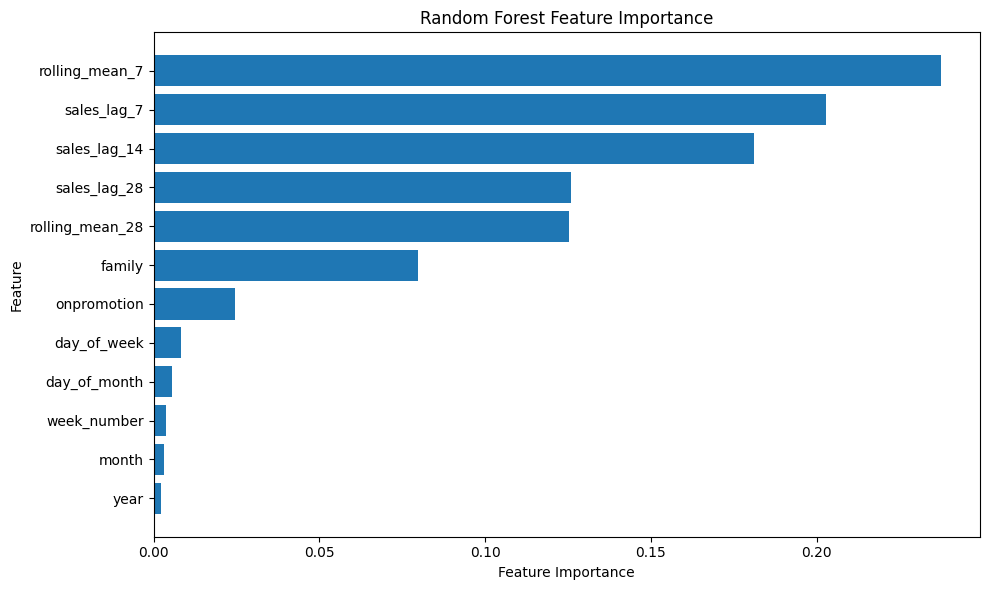

In [16]:
plt.figure(figsize=(10, 6))

plot_data = grouped_importance_df.sort_values(
    "Importance",
    ascending=True
)

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/retailiq_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
joblib.dump(
    final_model,
    "/kaggle/working/retailiq_final_model.pkl"
)

category_metrics_df.to_csv(
    "/kaggle/working/category_level_test_performance.csv",
    index=False
)

grouped_importance_df.to_csv(
    "/kaggle/working/grouped_feature_importance.csv",
    index=False
)

final_predictions_df = test_df[
    ["date", "family", "sales"]
].copy()

final_predictions_df["predicted_sales"] = final_test_predictions
final_predictions_df.to_csv(
    "/kaggle/working/final_test_predictions.csv",
    index=False
)

final_metrics_df = pd.DataFrame(
    [
        {
            "MAE": round(final_metrics["MAE"], 2),
            "RMSE": round(final_metrics["RMSE"], 2),
            "MAPE (%)": round(final_metrics["MAPE (%)"], 2),
            "WMAPE (%)": round(final_metrics["WMAPE (%)"], 2)
        }
    ]
)

final_metrics_df.to_csv(
    "/kaggle/working/final_model_metrics.csv",
    index=False
)

print("Files saved successfully:")
print("- retailiq_final_model.pkl")
print("- category_level_test_performance.csv")
print("- grouped_feature_importance.csv")
print("- final_test_predictions.csv")
print("- final_model_metrics.csv")
print("- retailiq_feature_importance.png")

Files saved successfully:
- retailiq_final_model.pkl
- category_level_test_performance.csv
- grouped_feature_importance.csv
- final_test_predictions.csv
- final_model_metrics.csv
- retailiq_feature_importance.png


In [18]:
anomaly_df = final_predictions_df.copy()

anomaly_df["residual"] = (
    anomaly_df["sales"]
    - anomaly_df["predicted_sales"]
)

residual_mean = anomaly_df["residual"].mean()
residual_std = anomaly_df["residual"].std()

anomaly_df["z_score"] = (
    anomaly_df["residual"]
    - residual_mean
) / residual_std

anomaly_threshold = 2.0

anomaly_df["is_anomaly"] = (
    anomaly_df["z_score"].abs()
    >= anomaly_threshold
)

print("Anomaly Detection Summary")
print("-------------------------")
print("Residual mean:", round(residual_mean, 2))
print("Residual standard deviation:", round(residual_std, 2))
print("Z-score threshold:", anomaly_threshold)
print("Total observations:", len(anomaly_df))
print("Detected anomalies:", int(anomaly_df["is_anomaly"].sum()))

anomaly_rate = (
    anomaly_df["is_anomaly"].mean()
    * 100
)

print(
    "Anomaly rate:",
    round(anomaly_rate, 2),
    "%"
)

Anomaly Detection Summary
-------------------------
Residual mean: -65.96
Residual standard deviation: 9469.44
Z-score threshold: 2.0
Total observations: 7491
Detected anomalies: 256
Anomaly rate: 3.42 %


In [19]:
detected_anomalies = (
    anomaly_df[
        anomaly_df["is_anomaly"]
    ]
    .sort_values(
        "z_score",
        key=lambda values: values.abs(),
        ascending=False
    )
)

print("Top detected anomalies:")
print(
    detected_anomalies[
        [
            "date",
            "family",
            "sales",
            "predicted_sales",
            "residual",
            "z_score"
        ]
    ].head(10).to_string(index=False)
)

Top detected anomalies:
      date    family      sales  predicted_sales       residual    z_score
2017-01-01 GROCERY I   1998.000    258152.091350 -256154.091350 -27.043634
2017-01-01 BEVERAGES   4008.000    227265.832651 -223257.832651 -23.569696
2017-01-02 GROCERY I 415182.950    270183.917677  144999.032323  15.319275
2017-04-01 GROCERY I 474003.906    329687.532934  144316.373066  15.247184
2017-01-01   PRODUCE   1682.844    144839.980111 -143157.136111 -15.110835
2017-05-01 GROCERY I 400850.633    269717.430317  131133.202683  13.855004
2017-01-02 BEVERAGES 335235.000    218521.084309  116713.915691  12.332286
2017-01-15 GROCERY I 329467.396    216656.647123  112810.748877  11.920101
2017-05-01 BEVERAGES 303807.000    192241.801052  111565.198948  11.788567
2017-01-15 BEVERAGES 301353.000    190934.291622  110418.708378  11.667494


In [20]:
final_anomaly_df = final_predictions_df.copy()

final_anomaly_df["residual"] = (
    final_anomaly_df["sales"]
    - final_anomaly_df["predicted_sales"]
)

family_residual_stats = (
    final_anomaly_df
    .groupby("family")["residual"]
    .agg(["mean", "std"])
    .reset_index()
)

family_residual_stats.columns = [
    "family",
    "residual_mean",
    "residual_std"
]

final_anomaly_df = final_anomaly_df.merge(
    family_residual_stats,
    on="family",
    how="left"
)

final_anomaly_df["z_score"] = (
    final_anomaly_df["residual"]
    - final_anomaly_df["residual_mean"]
) / final_anomaly_df["residual_std"]

anomaly_threshold = 2.0

final_anomaly_df["is_anomaly"] = (
    final_anomaly_df["z_score"].abs()
    >= anomaly_threshold
)

total_anomalies = int(
    final_anomaly_df["is_anomaly"].sum()
)

anomaly_rate = (
    final_anomaly_df["is_anomaly"].mean()
    * 100
)

print("Final Category-Level Anomaly Detection")
print("--------------------------------------")
print("Z-score threshold:", anomaly_threshold)
print("Total observations:", len(final_anomaly_df))
print("Detected anomalies:", total_anomalies)
print("Anomaly rate:", round(anomaly_rate, 2), "%")

Final Category-Level Anomaly Detection
--------------------------------------
Z-score threshold: 2.0
Total observations: 7491
Detected anomalies: 319
Anomaly rate: 4.26 %


In [21]:
final_detected_anomalies = (
    final_anomaly_df[
        final_anomaly_df["is_anomaly"]
    ]
    .copy()
)

final_detected_anomalies["absolute_z_score"] = (
    final_detected_anomalies["z_score"].abs()
)

final_detected_anomalies = (
    final_detected_anomalies
    .sort_values(
        "absolute_z_score",
        ascending=False
    )
)

print("Top Category-Level Anomalies")
print("----------------------------")

print(
    final_detected_anomalies[
        [
            "date",
            "family",
            "sales",
            "predicted_sales",
            "residual",
            "z_score"
        ]
    ].head(15).to_string(index=False)
)

Top Category-Level Anomalies
----------------------------
      date                     family       sales  predicted_sales       residual    z_score
2017-01-02            HOME APPLIANCES   40.000000       313.712695    -273.712695 -10.497020
2017-01-01                       DELI  195.975000     22442.230149  -22246.255149  -9.548268
2017-01-01               FROZEN FOODS  777.000000     29092.122275  -28315.122275  -9.511422
2017-08-14    PLAYERS AND ELECTRONICS  500.000000      2168.212230   -1668.212230  -9.463049
2017-05-13            LAWN AND GARDEN 6963.000000      1195.524057    5767.475943   9.171529
2017-01-01             PREPARED FOODS   56.198997      6548.584230   -6492.385233  -9.095040
2017-01-01                    PRODUCE 1682.844000    144839.980111 -143157.136111  -8.873710
2017-01-01                    POULTRY  154.199000     26265.288699  -26111.089699  -8.859742
2017-01-01                      MEATS  270.711000     20781.633147  -20510.922147  -8.637062
2017-01-01  

In [22]:
final_anomaly_df.to_csv(
    "/kaggle/working/final_anomaly_results.csv",
    index=False
)

final_detected_anomalies.to_csv(
    "/kaggle/working/detected_anomalies.csv",
    index=False
)

joblib.dump(
    final_model,
    "/kaggle/working/retailiq_final_model.pkl"
)

category_metrics_df.to_csv(
    "/kaggle/working/category_level_test_performance.csv",
    index=False
)

grouped_importance_df.to_csv(
    "/kaggle/working/grouped_feature_importance.csv",
    index=False
)

final_predictions_df.to_csv(
    "/kaggle/working/final_test_predictions.csv",
    index=False
)

final_metrics_df.to_csv(
    "/kaggle/working/final_model_metrics.csv",
    index=False
)

print("Final RetailIQ ML files saved successfully:")
print("- retailiq_final_model.pkl")
print("- final_model_metrics.csv")
print("- final_test_predictions.csv")
print("- category_level_test_performance.csv")
print("- grouped_feature_importance.csv")
print("- final_anomaly_results.csv")
print("- detected_anomalies.csv")

Final RetailIQ ML files saved successfully:
- retailiq_final_model.pkl
- final_model_metrics.csv
- final_test_predictions.csv
- category_level_test_performance.csv
- grouped_feature_importance.csv
- final_anomaly_results.csv
- detected_anomalies.csv


In [23]:
import json
import sklearn
import joblib
import pandas as pd
import numpy as np

model_path = "/kaggle/working/retailiq_final_model.pkl"

loaded_model = joblib.load(model_path)

sample_input = X_test.head(5)
sample_predictions = loaded_model.predict(sample_input)

print("Model reload test successful")
print("Model type:", type(loaded_model).__name__)
print("Scikit-learn version:", sklearn.__version__)
print("Joblib version:", joblib.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

print("\nSample predictions:")
for prediction in sample_predictions:
    print(round(float(prediction), 2))

environment_info = {
    "scikit-learn": sklearn.__version__,
    "joblib": joblib.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__
}

with open(
    "/kaggle/working/model_environment.json",
    "w"
) as file:
    json.dump(
        environment_info,
        file,
        indent=4
    )

print("\nmodel_environment.json saved successfully")

Model reload test successful
Model type: Pipeline
Scikit-learn version: 1.6.1
Joblib version: 1.5.3
Pandas version: 2.3.3
NumPy version: 2.0.2

Sample predictions:
477.07
857.6
817.7
819.17
798.39

model_environment.json saved successfully
